# Answer key: NFW dark matter density profile

This answer key shows how to define an NFW dark matter density function and plot the density as a function of Galactocentric radius. Vertical axis units: GeV cm^-3. Horizontal axis units: kpc.

Steps:

- Define `nfw_density(r_kpc, rs_kpc=..., rho_local=..., r_local=...)` returning density in GeV cm^-3.
- Compute densities over a radial grid (e.g., 0.1 -- 200 kpc).
- Plot using a log scale for density; label axes with units.

Students should compare `rho(8.2 kpc)` to the chosen local density (here set to 0.4 GeV/cm^3).

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def nfw_density(r_kpc, rs_kpc=20.0, rho_local=0.3, r_local=8.2):
    """
    NFW dark matter density profile (answer key)

    Parameters
    ----------
    r_kpc : float or array-like
        Radius in kpc (Galactocentric)
    rs_kpc : float
        Scale radius in kpc (default 20 kpc)
    rho_local : float
        Desired local density at `r_local` in GeV/cm^3 (default 0.4 GeV/cm^3)
    r_local : float
        Radius where `rho_local` is defined (kpc), e.g., Solar radius ~8.2 kpc

    Returns
    -------
    rho : float or ndarray
        Density in GeV/cm^3
    """
    r = np.asarray(r_kpc, dtype=float)
    # avoid division by zero at r=0
    r_safe = np.where(r == 0, 1e-8, r)

    # normalization rho0 set so that rho(r_local) = rho_local
    x_local = r_local / rs_kpc
    rho0 = rho_local * (x_local * (1.0 + x_local)**2)

    x = r_safe / rs_kpc
    rho = rho0 / (x * (1.0 + x)**2)
    return rho

# Quick docstring test (will not run unless executed)
# print(nfw_density(8.2))  # should be close to rho_local


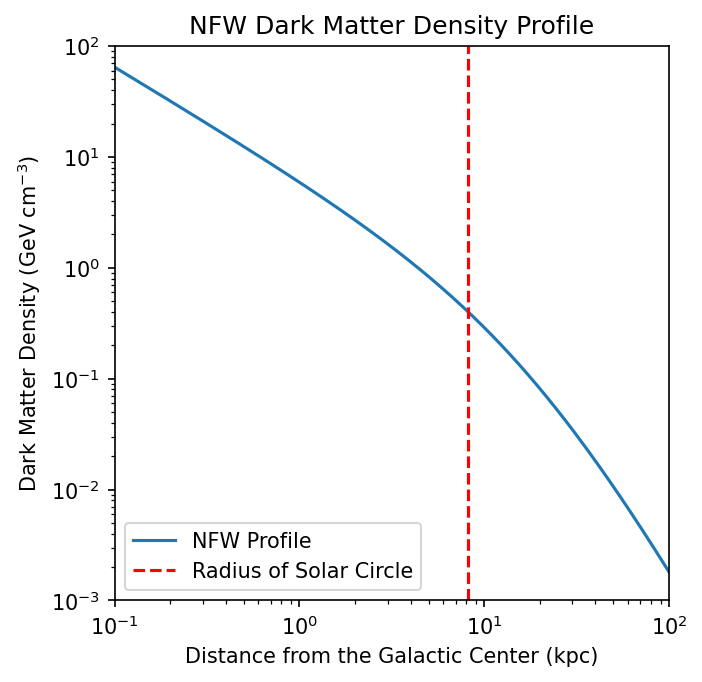

In [15]:
# Compute densities and make the plot
r = np.logspace(-1, 2, 300)  # 0.1 -- ~200 kpc
rho = nfw_density(r, rs_kpc=20.0, rho_local=0.4, r_local=8.2)

fig, ax = plt.subplots(1, 1, dpi=150)
ax.plot(r, rho, label='NFW Profile')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Distance from the Galactic Center (kpc)')
ax.set_ylabel(r'Dark Matter Density (GeV cm$^{-3}$)')
ax.set_title('NFW Dark Matter Density Profile')

ax.vlines(8.2, 1e-3, 1e2, colors='red', linestyles='dashed', label='Radius of Solar Circle')

ax.set_xlim(0.1, 100)
ax.set_ylim(1e-3,1e2)

ax.legend(loc='lower left')

ax.set_box_aspect(1)
plt.savefig('example_nfw_plot.png', bbox_inches='tight')
plt.show()